# Load data

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = pd.read_csv('iris.csv')

# Check for missing values
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  149 non-null    float64
 1   sepal_width   149 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   148 non-null    float64
 4   target        150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


# Preprocessing

In [99]:
# Handle rows with missing values
iris.dropna(inplace=True)

# Define data
X = iris.iloc[:, :2].values  # we only take the first two features for visualization purposes
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Model training

In [ ]:
# Train kNN classifier
knn = KNeighborsClassifier(n_neighbors=)
knn.fit(X_train_std, y_train)

# Train Naive Bayes classifier
nb = GaussianNB()
nb.fit(X_train_std, y_train);

# Testing the model

In [101]:
# Calculate accuracy for training and testing sets
knn_train_accuracy = accuracy_score(y_train, knn.predict(X_train_std))
knn_test_accuracy = accuracy_score(y_test, knn.predict(X_test_std))

nb_train_accuracy = accuracy_score(y_train, nb.predict(X_train_std))
nb_test_accuracy = accuracy_score(y_test, nb.predict(X_test_std))

print("kNN Training Accuracy:", round(knn_train_accuracy, 2))
print("kNN Testing Accuracy:", round(knn_test_accuracy, 2))

print("Naive Bayes Training Accuracy:", round(nb_train_accuracy, 2))
print("Naive Bayes Testing Accuracy:", round(nb_test_accuracy, 2))

kNN Training Accuracy: 0.72
kNN Testing Accuracy: 0.84
Naive Bayes Training Accuracy: 0.75
Naive Bayes Testing Accuracy: 0.84


# Visualize decision boundary

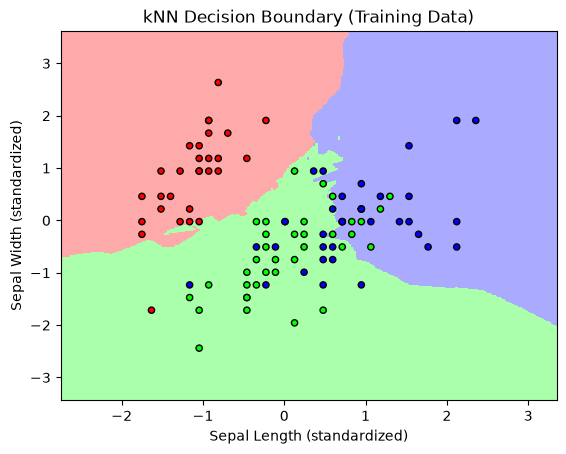

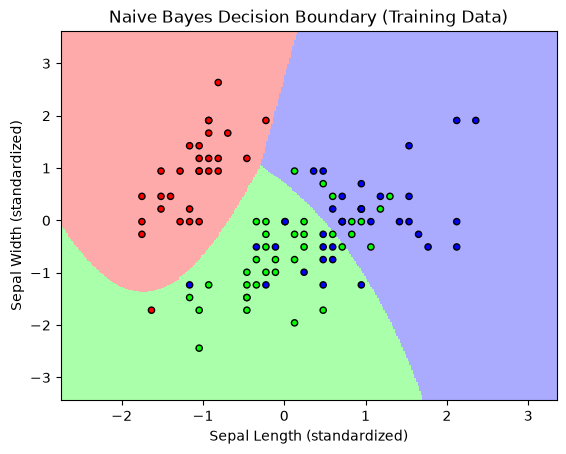

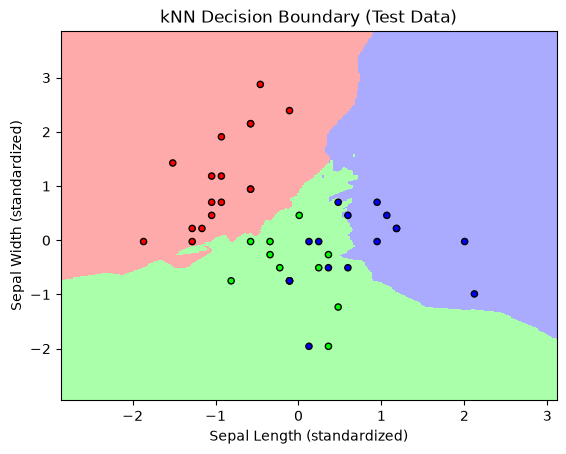

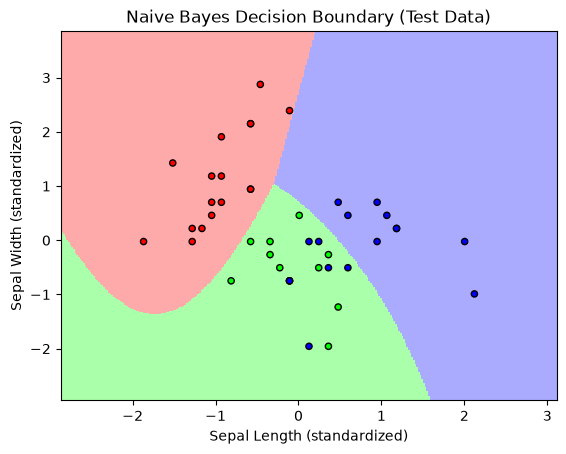

In [102]:
# Define a colormap for plotting decision regions
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# Function to plot the decision boundaries
def plot_decision_boundary(classifier, X, y, title):
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Sepal Length (standardized)')
    plt.ylabel('Sepal Width (standardized)')
    plt.title(title)

# Plot decision boundaries with training data
plot_decision_boundary(knn, X_train_std, y_train, 'kNN Decision Boundary (Training Data)')
plt.show()

plot_decision_boundary(nb, X_train_std, y_train, 'Naive Bayes Decision Boundary (Training Data)')
plt.show()

# Plot decision boundaries with test data
plot_decision_boundary(knn, X_test_std, y_test, 'kNN Decision Boundary (Test Data)')
plt.show()

plot_decision_boundary(nb, X_test_std, y_test, 'Naive Bayes Decision Boundary (Test Data)')
plt.show()